In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
df["Income"]=df["Income"].fillna(df["Income"].median)

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [8]:
df["age"]=2026-df["Year_Birth"]

In [9]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [10]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
ref_date=df["Dt_Customer"].max()
df["cust_tenure_day"]=(ref_date-df["Dt_Customer"]).dt.days

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,cust_tenure_day
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
df["tot_spend"]=df["MntWines"]+df["MntGoldProds"]+df["MntMeatProducts"]+df["MntFruits"]+df["MntSweetProducts"]+df["MntFishProducts"]

In [14]:
df["tot_child"]=df["Kidhome"]+df["Teenhome"]

In [15]:
df["Education"].value_counts()
df["Education"]=df["Education"].replace(
    {
        "Basic":"Undergrad","2n Cycle" : "Undergrad",
        "Graduation":"Grad",
        "PhD":"post","Master":"post"
    })


In [16]:
df["Education"].value_counts()

Education
Grad         1127
post          856
Undergrad     257
Name: count, dtype: int64

In [17]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [18]:

df["Living_with"]=df["Marital_Status"].replace(
    {
        "Married":"Partner","Together" : "Partner",
        "Single":"Alone",
        "Divorced":"Alone","Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
    })

In [19]:
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   object        
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [21]:
cols_to_drop=["ID","Marital_Status","Year_Birth","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

In [22]:
df_clean=df.drop(columns=cols_to_drop)

In [23]:
df_clean

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,cust_tenure_day,tot_spend,tot_child,Living_with
0,Grad,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Grad,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Grad,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Grad,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,post,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Grad,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,Partner
2236,post,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,Partner
2237,Grad,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,Alone
2238,post,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,Partner


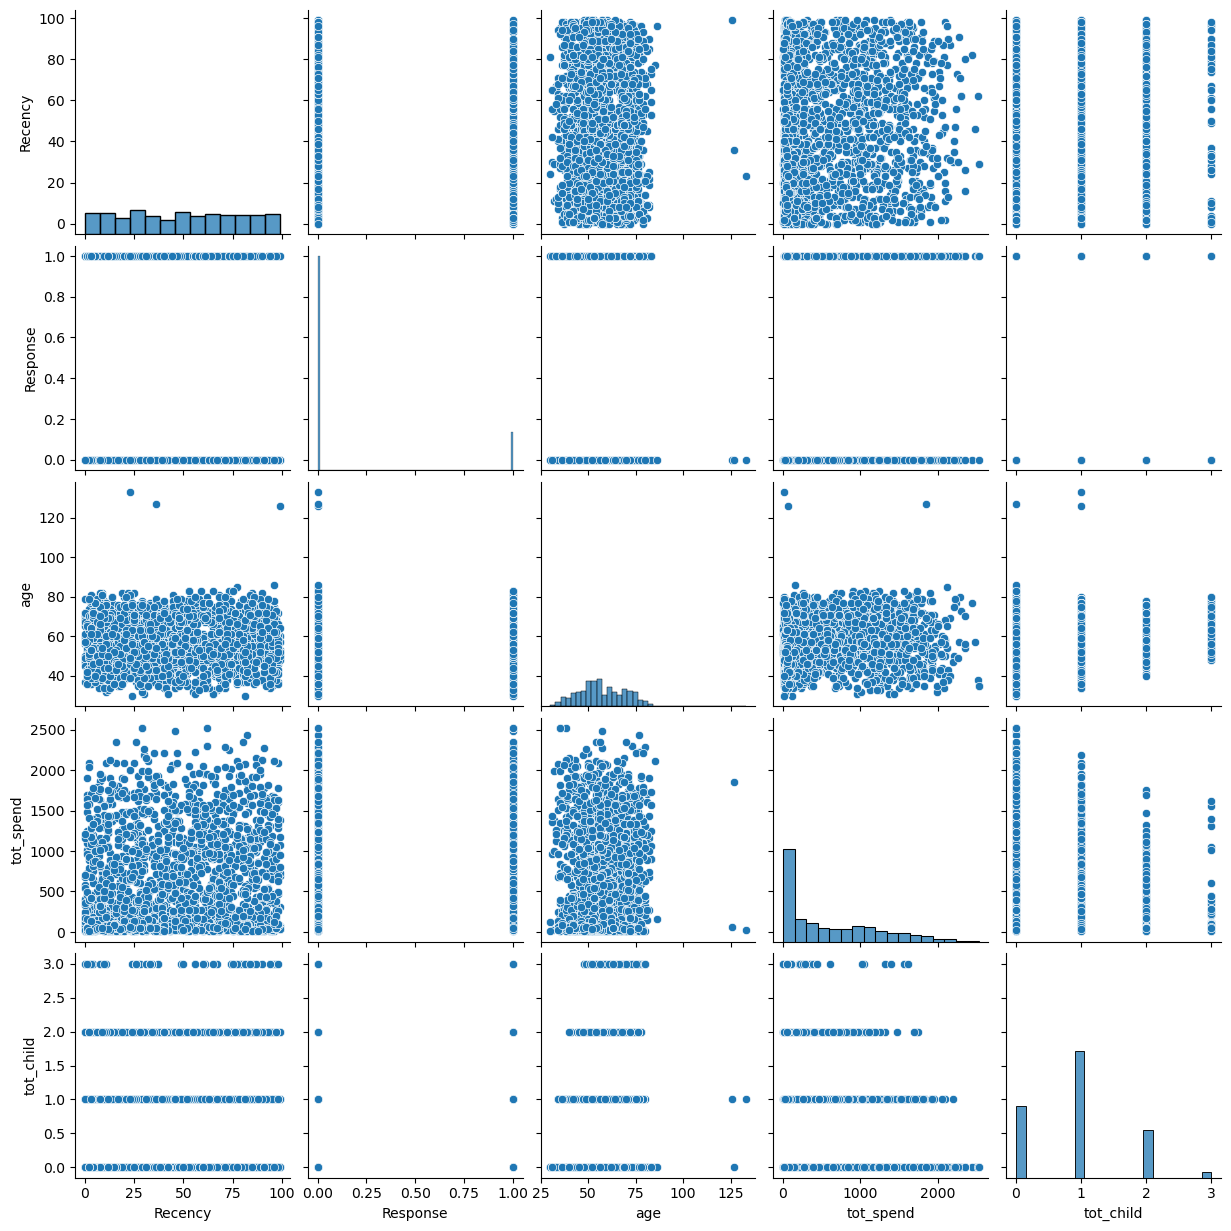

In [24]:
cols=["Income","Recency","Response","age","tot_spend","tot_child"]
sns.pairplot(df_clean[cols])

In [25]:
#removing outliers
print("data size with outliers ",len(df_clean))
df_clean["Income"] = pd.to_numeric(df_clean["Income"], errors="coerce")
df_clean=df_clean[(df_clean["age"]<90)]
df_clean=df_clean[(df_clean["Income"]<125_000)]
print("data size without outliers ",len(df_clean))

data size with outliers  2240
data size without outliers  2205


In [26]:
corr=df_clean.corr(numeric_only=True)


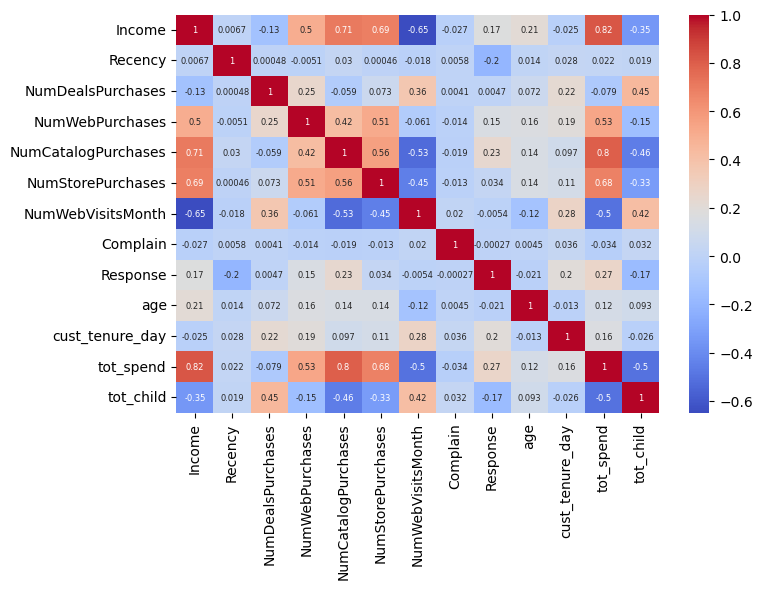

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm")
plt.tight_layout()

In [28]:
#one hot encoding
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_cols=["Living_with","Education"]
enc_cols=ohe.fit_transform(df_clean[cat_cols])

In [29]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_clean.index)

In [30]:
enc_df.head()

,Living_with_Alone,Living_with_Partner,Education_Grad,Education_Undergrad,Education_post
0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,0.0
3,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,1.0


In [31]:
enc_df=pd.concat([df_clean.drop(columns=cat_cols),enc_df],axis=1)

In [32]:

enc_df.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,cust_tenure_day,tot_spend,tot_child,Living_with_Alone,Living_with_Partner,Education_Grad,Education_Undergrad,Education_post
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,1.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,1.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,1.0,0.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,1.0,0.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [33]:
X=enc_df
scaler=StandardScaler()
X_scaler=scaler.fit_transform(X)


In [34]:
X_scaler

array([[ 0.31465086,  0.31083003,  0.36147864, ...,  0.99052111,
        -0.3592106 , -0.78446454],
       [-0.25487741, -0.38060021, -0.16883433, ...,  0.99052111,
        -0.3592106 , -0.78446454],
       [ 0.96535404, -0.79545835, -0.6991473 , ...,  0.99052111,
        -0.3592106 , -0.78446454],
       ...,
       [ 0.25877972,  1.45168993, -0.6991473 , ...,  0.99052111,
        -0.3592106 , -0.78446454],
       [ 0.85100412, -1.41774556, -0.16883433, ..., -1.0095696 ,
        -0.3592106 ,  1.27475488],
       [ 0.06021263, -0.31145718,  0.36147864, ..., -1.0095696 ,
        -0.3592106 ,  1.27475488]], shape=(2205, 18))

VISUALIZE

In [35]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaler)

Text(0.5, 0, 'PCA3')

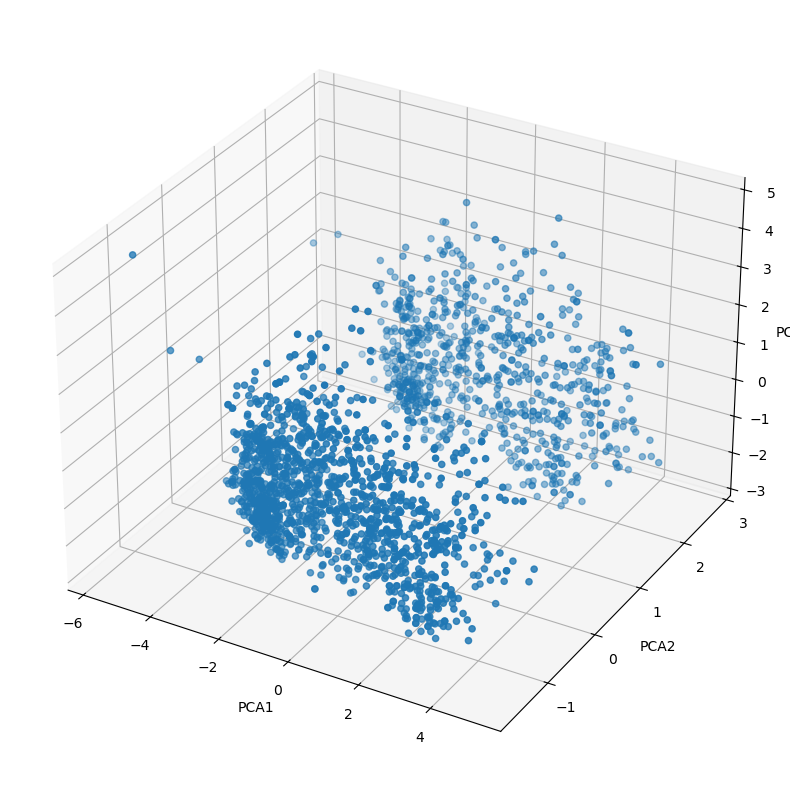

In [36]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")


In [37]:
pca.explained_variance_ratio_

array([0.23824671, 0.11383479, 0.10451458])

FINDING K

In [38]:
from sklearn.cluster import KMeans

from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    km=KMeans(
        n_clusters=k,
        random_state=42)
    labels=km.fit_predict(X_pca)
    wcss.append(km.inertia_)
    

In [39]:
kn=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
print(kn.knee)

4


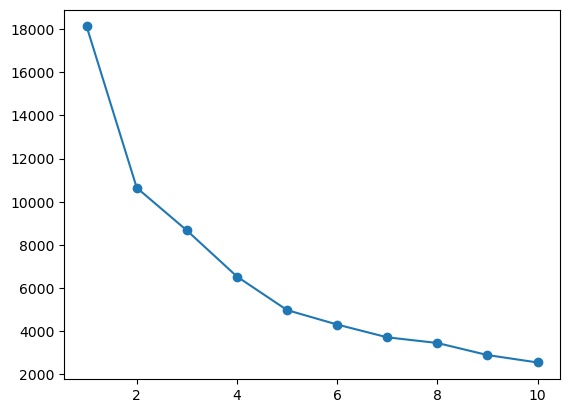

In [40]:
plt.plot(range(1,11),wcss,marker="o")

Text(0.5, 0, 'PCA3')

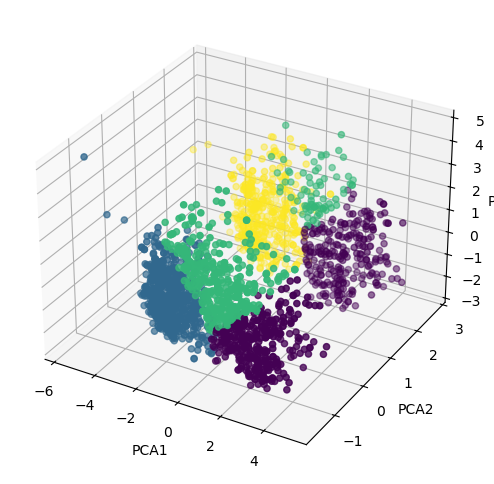

In [47]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42)
k_labels=kmeans.fit_predict(X_pca)
fig=plt.figure(figsize=(6,8))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=k_labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")


Text(0.5, 0, 'PCA3')

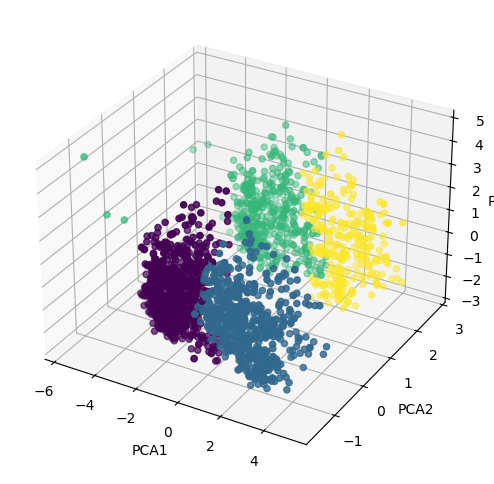

In [46]:
from sklearn.cluster import AgglomerativeClustering
agg=AgglomerativeClustering(
    n_clusters=4,
    linkage="ward")
a_labels=agg.fit_predict(X_pca)
fig=plt.figure(figsize=(6,8))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=a_labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

In [52]:
X["clusters"]=a_labels
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,cust_tenure_day,tot_spend,tot_child,Living_with_Alone,Living_with_Partner,Education_Grad,Education_Undergrad,Education_post,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,1.0,0.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,1.0,0.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,1.0,0.0,0.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,1.0,0.0,0.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

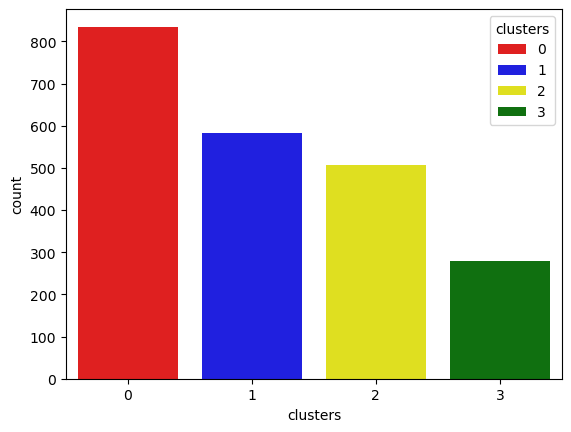

In [53]:
pal=["red","blue","yellow","green"]
sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])

<Axes: xlabel='tot_spend', ylabel='Income'>

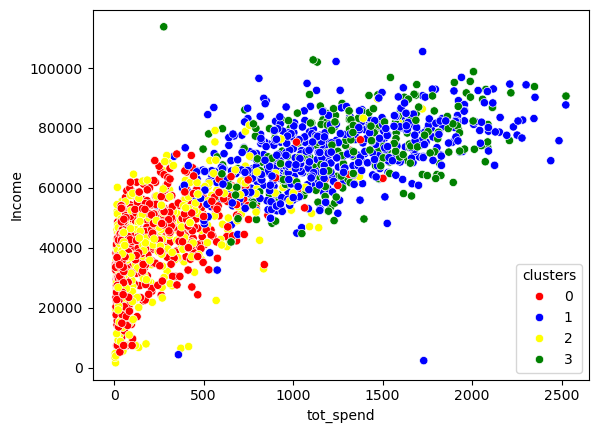

In [54]:
sns.scatterplot(x=X["tot_spend"],y=X["Income"],hue=X["clusters"],palette=pal)

In [56]:
cluster_summary=X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         38176.638323  48.985629           2.603593         2.941317   
1         70619.101027  49.017123           1.970890         5.799658   
2         40072.745059  47.970356           2.616601         3.166008   
3         72967.364286  50.939286           1.653571         5.703571   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.839521           3.894611           6.440719  0.008383   
1                    5.142123           8.643836           3.710616  0.010274   
2                    1.150198           4.207510           6.444664  0.009881   
3                    5.525000           8.614286           3.435714  0.007143   

          Response        age  cust_tenure_day    tot_spend  tot_child  \
